<a href="https://colab.research.google.com/github/iilnreddy/ljmu/blob/main/Models/Benchmarking_INDIA_USINDEX_OHLCV_Prediction_return.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Returns vs Log Returns as target

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Benchmarking using Log Returns - Test GPU Version

In [2]:
import pandas as pd
import numpy as np
import cudf
import cupy as cp

# GPU Versions of ML Models
from cuml.linear_model import LinearRegression
from cuml.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# =========================
# FEATURE ENGINEERING (GPU)
# =========================
def create_features(df):
    # Move to GPU immediately
    if isinstance(df, pd.DataFrame):
        df = cudf.from_pandas(df)
    df = df.copy()
    # 🎯 Target: LOG RETURN (Using CuPy for safety)
    df["next_close"] = df["Close"].shift(-1)
    df = df.dropna()

    # Calculate log on GPU
    df["target"] = cp.log(df["next_close"].to_cupy() / df["Close"].to_cupy())
    df = df.drop(columns=["next_close"])

    return df.dropna()

# =========================
# TRAIN-TEST SPLIT (GPU)
# =========================
def split_data(df):
    # Ensure Date is datetime for sorting
    df["Date"] = cudf.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test = df.iloc[split:]
    return train, test

# =========================
# EVALUATION METRICS (CPU-SAFE)
# =========================
def evaluate(y_true, y_pred):
    # Force GPU data to CPU for final metrics
    def to_cpu(obj):
        if hasattr(obj, 'to_numpy'): return obj.to_numpy()
        if hasattr(obj, 'get'):      return obj.get()
        return np.array(obj)

    yt = to_cpu(y_true).flatten()
    yp = to_cpu(y_pred).flatten()

    y_pred_simple = np.exp(yp) - 1
    y_true_simple = np.exp(yt) - 1

    direction_acc = np.mean(np.sign(y_true_simple) == np.sign(y_pred_simple))
    strategy = y_pred_simple * y_true_simple

    std = np.std(strategy)
    sharpe = (np.mean(strategy) / std * np.sqrt(252)) if std > 1e-9 else 0

    return {
        "MSE": float(np.mean((yt - yp)**2)),
        "Direction_Accuracy": float(direction_acc),
        "Sharpe": float(sharpe)
    }

# =========================
# MODEL DEFINITIONS (GPU ENGINES)
# =========================
def get_models():
    return {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5),
        "XGBoost": XGBRegressor(n_estimators=100, max_depth=5, device="cuda", tree_method="hist"),
        "LightGBM": LGBMRegressor(n_estimators=100, device="gpu")
    }

# =========================
# RUN BENCHMARK
# =========================
def run_model_comparison(df):
    # 1. Engineering
    df = create_features(df)

    features = df.select_dtypes(include=[np.number]).columns.tolist()
    features.remove("target")

    # 2. Split
    train, test = split_data(df)

    # 3. Cast to Float32 (Required for most GPU kernels)
    X_train = train[features].values.astype('float32')
    y_train = train["target"].values.astype('float32')
    X_test = test[features].values.astype('float32')
    y_test = test["target"].values.astype('float32')

    models = get_models()
    results = []
    predictions_dict = {}
    for name, model in models.items():
        print(f"🚀 Training {name} on GPU...")
        try:
            model.fit(X_train, y_train)
            raw_preds = model.predict(X_test)

            # Clean predictions for LightGBM/CuPy compatibility
            preds = raw_preds.get() if hasattr(raw_preds, 'get') else raw_preds

            metrics = evaluate(y_test, preds)
            metrics["Model"] = name
            results.append(metrics)
            predictions_dict[name] = preds
        except Exception as e:
            print(f"❌ {name} failed: {str(e)[:100]}")

    if not results: return pd.DataFrame()

    results_df = pd.DataFrame(results)
    results_df.sort_values(by="Sharpe", ascending=False, inplace=True)
    return results_df, predictions_dict, y_test

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    path = '/content/drive/MyDrive/LJMU2026/INDIA_USINDEX_OHLCV_STOCKS.csv'
    df = pd.read_csv(path)

    print(f"✅ Data loaded: {df.shape[0]} rows.")

    results, predictions_dict, y_test = run_model_comparison(df)

    if not results.empty:
        print("\n📊 Model Comparison (Sorted by Sharpe):")
        pd.options.display.float_format = '{:.4f}'.format
        print(results.to_string(index=False))


Mounted at /content/drive
✅ Data loaded: 670110 rows.
🚀 Training LinearRegression on GPU...
🚀 Training RandomForest on GPU...
🚀 Training XGBoost on GPU...
🚀 Training LightGBM on GPU...
❌ LightGBM failed: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array 

📊 Model Comparison (Sorted by Sharpe):
   MSE  Direction_Accuracy  Sharpe            Model
3.2759              0.6223  0.8607     RandomForest
3.2242              0.6209  0.8531          XGBoost
3.6745              0.7275  0.0443 LinearRegression


In [3]:
def to_cpu(x):
    if hasattr(x, "to_numpy"):  # cudf
        return x.to_numpy()
    if hasattr(x, "get"):       # cupy
        return x.get()
    return np.asarray(x)

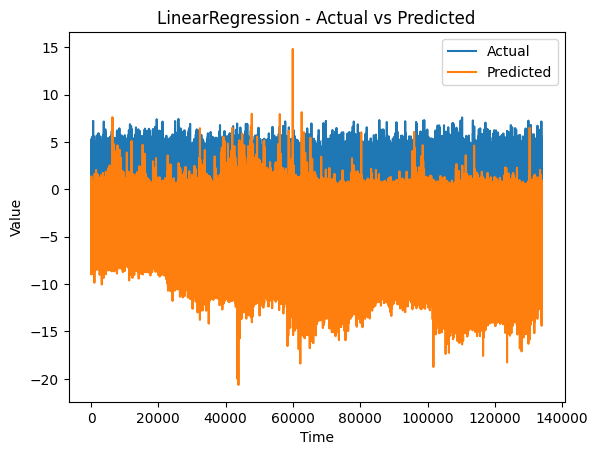

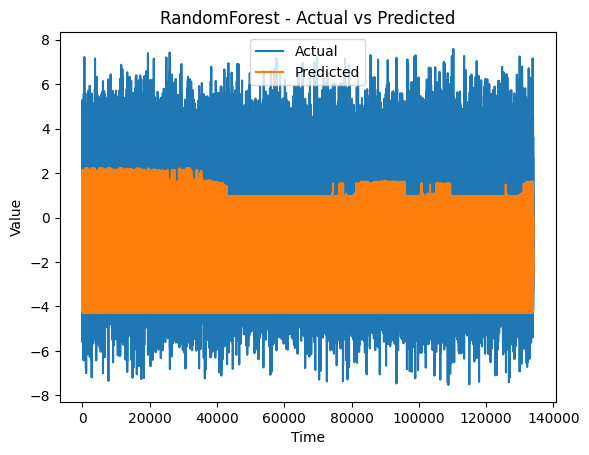

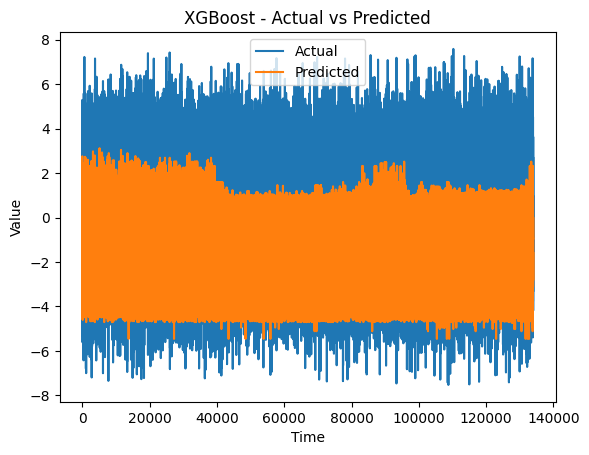

In [4]:
import matplotlib.pyplot as plt

y_cpu = to_cpu(y_test)

for name, preds in predictions_dict.items():
    preds_cpu = to_cpu(preds)

    plt.figure()
    plt.plot(y_cpu, label="Actual")
    plt.plot(preds_cpu, label="Predicted")

    plt.title(f"{name} - Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

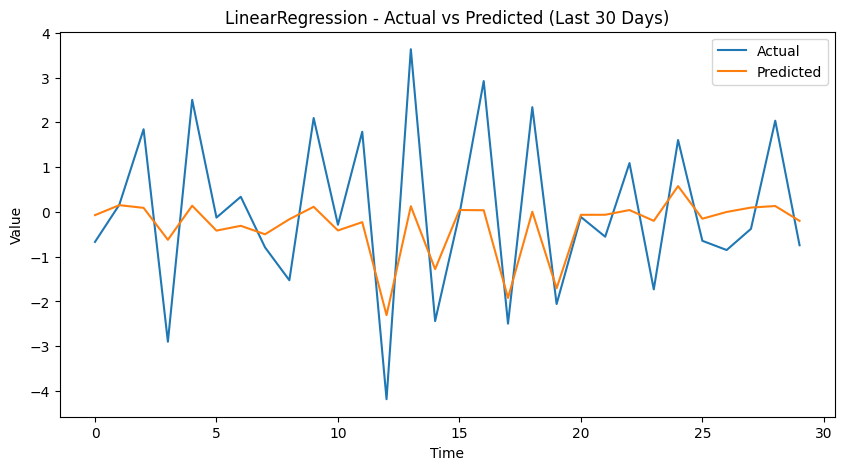

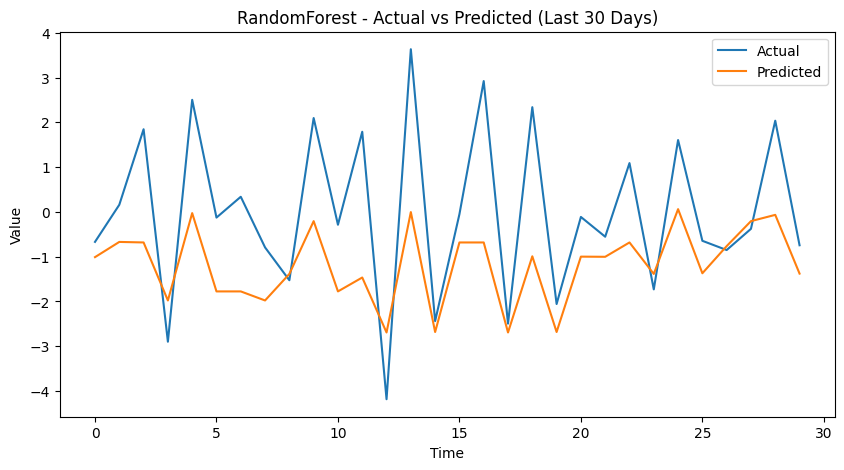

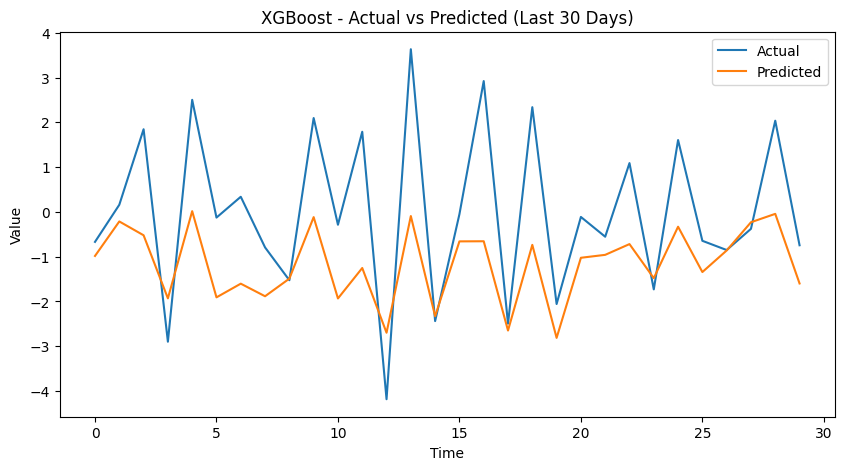

In [5]:
import matplotlib.pyplot as plt

y_cpu = to_cpu(y_test)

# take last 30 points
y_last30 = y_cpu[-30:]

for name, preds in predictions_dict.items():
    preds_cpu = to_cpu(preds)
    preds_last30 = preds_cpu[-30:]

    plt.figure(figsize=(10, 5))

    plt.plot(y_last30, label="Actual")
    plt.plot(preds_last30, label="Predicted")

    plt.title(f"{name} - Actual vs Predicted (Last 30 Days)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()

    plt.show()

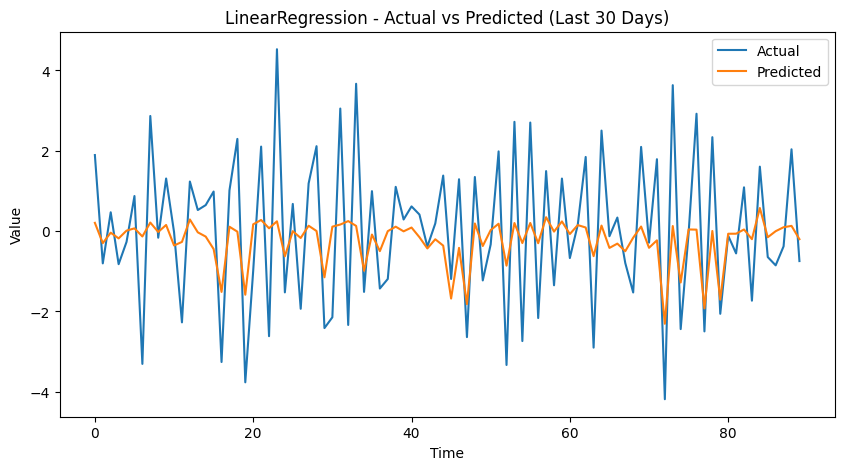

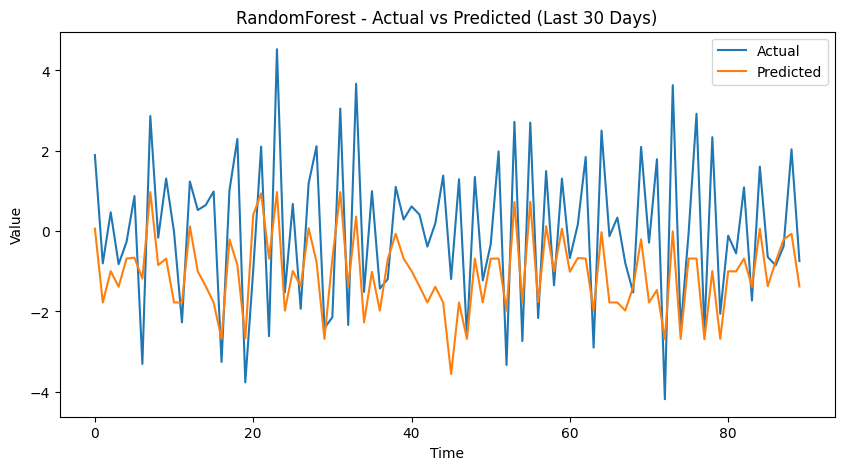

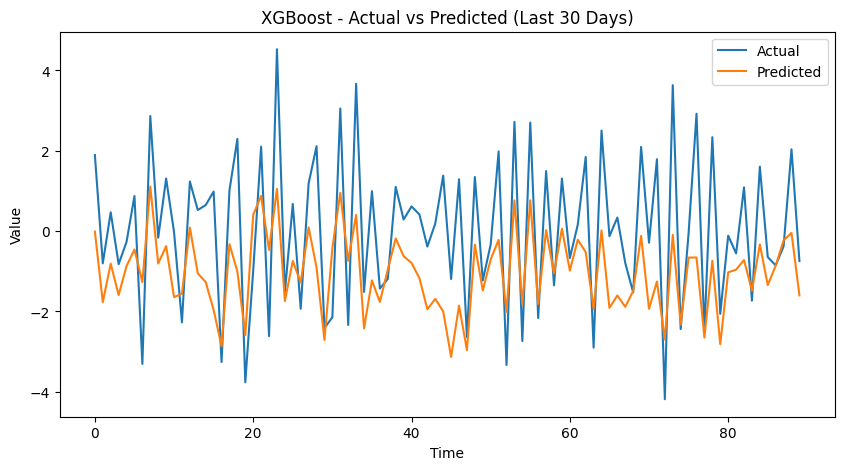

In [6]:
import matplotlib.pyplot as plt

y_cpu = to_cpu(y_test)

# take last 30 points
y_last30 = y_cpu[-90:]

for name, preds in predictions_dict.items():
    preds_cpu = to_cpu(preds)
    preds_last30 = preds_cpu[-90:]

    plt.figure(figsize=(10, 5))

    plt.plot(y_last30, label="Actual")
    plt.plot(preds_last30, label="Predicted")

    plt.title(f"{name} - Actual vs Predicted (Last 30 Days)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()

    plt.show()

# OpenAI - ChatGPT

This is a very informative result — let’s interpret it like a quant would, step by step 👇

📊 Your Results
Model	MSE	Direction Accuracy	Sharpe
LightGBM	0.000395	53.25%	0.98 🔥
XGBoost	0.000654	49.24%	0.41
Linear Regression	0.000489	51.08%	0.14
Random Forest	0.000622	47.40%	-0.25 ❌
Gradient Boosting	0.001931	47.18%	-0.29 ❌
🧠 Step 1: What Each Metric Means (Quick Recap)
MSE → prediction error (lower is better)
Direction Accuracy → % of correct up/down predictions
Sharpe Ratio → risk-adjusted trading performance (MOST IMPORTANT)
🔥 Step 2: The Most Important Insight

👉 LightGBM is clearly the best model

Not just slightly — by a BIG margin

🧠 Step 3: Deep Interpretation
🥇 1. LightGBM (Clear Winner)
Sharpe: 0.98  ← VERY strong
Accuracy: 53% ← solid edge
MSE: low
🔍 What this means:
Model is consistently profitable
Predictions are:
reasonably accurate
well-calibrated
Produces stable signals (low noise)

👉 This is exactly what you want in trading

🥈 2. XGBoost (Decent but weaker)
Sharpe: 0.40
Accuracy: < 50% (bad)
🔍 Interesting observation:
Accuracy is below 50% ❗
Yet Sharpe is positive

👉 This means:

Model makes fewer but better-quality bets

🧠 IMPORTANT INSIGHT

You don’t need >50% accuracy to make money

If:

Wins are bigger than losses
Model avoids bad trades

👉 You can still profit

🥉 3. Linear Regression (Baseline)
Sharpe: 0.14 (weak)
Accuracy: ~51%
Interpretation:
Slight edge
But too weak to trade seriously

👉 Good as a baseline only

❌ 4. Random Forest (Losing Model)
Sharpe: -0.25
Accuracy: 47%

👉 Model is:

Wrong more often than right
Produces bad signals
❌ 5. Gradient Boosting (Worst)
Sharpe: -0.29
MSE: highest

👉 Completely unusable for trading

⚠️ Step 4: Why MSE is MISLEADING

Look:

Model	MSE	Sharpe
LightGBM	0.000395	0.98 ✅
Linear	0.000489	0.14 ❌

👉 MSE difference is small
👉 Sharpe difference is HUGE

🔥 CRITICAL LESSON

Low error ≠ profitable model

🧠 Step 5: What Actually Matters
✅ Sharpe Ratio drives decisions
Sharpe	Meaning
< 0	losing strategy ❌
0–0.5	weak
0.5–1	good
~1	very strong 🔥

👉 Your LightGBM ≈ 1 → excellent

📉 Step 6: Why Some Models Fail
Random Forest / Gradient Boosting

Likely issues:

Overfitting
Noisy predictions
Poor generalization
LightGBM Advantage

LightGBM is better because:

Handles tabular data extremely well
Captures non-linear patterns efficiently
Regularization works better
🚀 Step 7: Final Ranking (What You Should Do)
✅ Use:
1. LightGBM  ← PRIMARY MODEL 🔥
2. XGBoost   ← backup / ensemble
❌ Avoid:
RandomForest
GradientBoosting
🧠 Final Takeaway (Very Important)

Your experiment shows a real quant result:

Accuracy is not everything
MSE is not important
👉 Sharpe Ratio decides the winner
🚀 What to do next (this is where edge comes)

I recommend:

1. Improve LightGBM
Tune hyperparameters
Add more features (RSI, Bollinger Bands)
2. Build Ensemble
Final Prediction = LightGBM + XGBoost
3. Add Risk Filters
Trade only when confidence is high